## AMR Modelling pipeline

#### Libarary imports

In [1]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap


#### Load Data already preprocessed

In [2]:
df = pd.read_csv('../Data/processed/amr_final_v2.csv')

#### Build 4 drug-class targets

In [3]:
DRUG_CLASSES = {
    'target_beta_lactam'   : ['amoxicillin_ampicillin','amoxicillin_clavulanate',
                               'cefazolin','cefoxitin','cefotaxime_ceftriaxone','imipenem'],
    'target_aminoglycoside': ['gentamicin','amikacin'],
    'target_quinolone'     : ['nalidixic_acid','ofloxacin','ciprofloxacin'],
    'target_other'         : ['chloramphenicol','cotrimoxazole','nitrofurantoin','colistin'],
}

for target, ab_cols in DRUG_CLASSES.items():
    present = [c for c in ab_cols if c in df.columns]
    vals = df[present].replace(-1, np.nan)
    df[target] = np.where(vals.eq(2).any(axis=1), 2,
                 np.where(vals.eq(1).any(axis=1), 1, 0))
    df[target] = df[target].where(vals.notna().any(axis=1), np.nan)

TARGET_COLS = list(DRUG_CLASSES.keys())

print("Target distributions:")
for t in TARGET_COLS:
    print(f"  {t}: {df[t].value_counts(dropna=False).to_dict()}")

# ── Engineered features (required by quinolone & other models) ───────────────
df['gene_mechanism_ratio'] = df['card_mechanism_diversity'] / (df['card_relevant_gene_count'] + 1)
df['gene_density']         = df['card_relevant_gene_count'] / (df['card_gene_family_diversity'] + 1)
df['mechanism_density']    = df['card_n_active_drug_classes'] / (df['card_gene_family_diversity'] + 1)

# ── Per-drug-class curated feature sets ──────────────────────────────────────
# These are used by: model training, CV, AND SHAP — must stay consistent
DRUG_CLASS_FEATURES = {
    'target_beta_lactam': [
        'species_enc', 'age', 'card_relevant_gene_count',
        'card_has_oxa_48', 'card_has_vim', 'card_gene_family_diversity',
        'card_has_kpc', 'card_has_tem', 'card_has_imp',
    ],
    'target_aminoglycoside': [
        'age', 'card_relevant_gene_count', 'card_gene_family_diversity',
        'species_enc', 'card_n_active_drug_classes', 'card_mechanism_diversity',
        'prior_hospitalisation', 'has_hypertension', 'has_diabetes',
        'gender_enc', 'is_mdr', 'total_antibiotics_tested',
    ],
    'target_quinolone': [
        'card_has_qnr', 'age', 'card_has_target_protection',
        'card_mechanism_diversity', 'card_relevant_gene_count',
        'species_enc', 'card_gene_family_diversity', 'gene_mechanism_ratio',
    ],
    'target_other': [
        'age', 'card_n_active_drug_classes', 'species_enc',
        'card_relevant_gene_count', 'card_gene_family_diversity',
        'gene_density', 'mechanism_density',
    ],
}

print("\nPer-class feature counts:")
for t, feats in DRUG_CLASS_FEATURES.items():
    print(f"  {t}: {len(feats)} features -> {feats}")


Target distributions:
  target_beta_lactam: {2: 9688, 0: 455, 1: 88}
  target_aminoglycoside: {0: 6510, 2: 3490, 1: 231}
  target_quinolone: {0: 6323, 2: 3690, 1: 218}
  target_other: {0.0: 5652, 2.0: 4200, nan: 274, 1.0: 105}

Per-class feature counts:
  target_beta_lactam: 9 features -> ['species_enc', 'age', 'card_relevant_gene_count', 'card_has_oxa_48', 'card_has_vim', 'card_gene_family_diversity', 'card_has_kpc', 'card_has_tem', 'card_has_imp']
  target_aminoglycoside: 12 features -> ['age', 'card_relevant_gene_count', 'card_gene_family_diversity', 'species_enc', 'card_n_active_drug_classes', 'card_mechanism_diversity', 'prior_hospitalisation', 'has_hypertension', 'has_diabetes', 'gender_enc', 'is_mdr', 'total_antibiotics_tested']
  target_quinolone: 8 features -> ['card_has_qnr', 'age', 'card_has_target_protection', 'card_mechanism_diversity', 'card_relevant_gene_count', 'species_enc', 'card_gene_family_diversity', 'gene_mechanism_ratio']
  target_other: 7 features -> ['age', 'ca

#### Per-target modelling

In [4]:
# ── Shared hyperparameter search grid ────────────────────────────────────────
param_grid = {
    'n_estimators':     [200, 300, 400, 500],
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'subsample':        [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'gamma':            [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5, 7],
}

CLASS_NAMES    = {0: 'Susceptible', 1: 'Intermediate', 2: 'Resistant'}
results        = {}
trained_models = {}
best_params_all = {}
# Store per-target (X_test, y_test, y_pred, y_prob, features) for later cells
eval_store     = {}

print("Hyperparameter grid defined.")
print("param_grid keys:", list(param_grid.keys()))


Hyperparameter grid defined.
param_grid keys: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'min_child_weight']


In [5]:
os.makedirs('../outputs', exist_ok=True)

for target in TARGET_COLS:
    print(f"\n{'='*65}")
    print(f"TARGET: {target}")
    print('='*65)

    features = DRUG_CLASS_FEATURES[target]   # per-class curated features

    data = df[df[target].notna()].copy()
    X    = data[features].fillna(0)
    y    = data[target].astype(int)

    print(f"Class distribution : {y.value_counts().to_dict()}")
    print(f"Features ({len(features)}): {features}")

    # ── Train / test split ───────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # ── SMOTE ────────────────────────────────────────────────────────────────
    min_class_count = y_train.value_counts().min()
    k = min(5, min_class_count - 1)
    if k >= 1:
        sm = SMOTE(random_state=42, k_neighbors=k)
        X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
    else:
        X_train_sm, y_train_sm = X_train, y_train
    print(f"After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

    # ── Step 1 : Hyperparameter Tuning ───────────────────────────────────────
    print(f"\n[Tuning] RandomizedSearchCV (n_iter=30, cv=3) ...")
    xgb_base = XGBClassifier(
        objective='multi:softmax', num_class=3, eval_metric='mlogloss',
        use_label_encoder=False, random_state=42, n_jobs=-1,
    )
    random_search = RandomizedSearchCV(
        estimator=xgb_base, param_distributions=param_grid,
        n_iter=30, scoring='f1_weighted', cv=3,
        verbose=1, random_state=42, n_jobs=-1,
    )
    random_search.fit(X_train_sm, y_train_sm)

    best_params = random_search.best_params_
    best_params_all[target] = best_params
    print(f"Best params: {best_params}")

    # ── Step 2 : Build final model with best params ───────────────────────────
    print(f"\n[Model] Fitting final model with best params ...")
    sample_weights = compute_sample_weight('balanced', y_train_sm)
    model = XGBClassifier(
        objective='multi:softmax', num_class=3, eval_metric='mlogloss',
        use_label_encoder=False, random_state=42, n_jobs=-1,
        **best_params,
    )
    model.fit(X_train_sm, y_train_sm, sample_weight=sample_weights)
    trained_models[target] = model

    # ── Step 3 : Evaluation ───────────────────────────────────────────────────
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    wf1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mf1 = f1_score(y_test, y_pred, average='macro',    zero_division=0)
    acc = (y_test.values == y_pred).mean()

    classes_present = sorted(y_test.unique())
    if len(classes_present) == 3:
        y_bin = label_binarize(y_test, classes=[0, 1, 2])
        auc   = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
    else:
        auc = np.nan

    # 5-fold CV
    cv_scores = cross_val_score(
        XGBClassifier(objective='multi:softmax', num_class=3,
                      eval_metric='mlogloss', use_label_encoder=False,
                      random_state=42, n_jobs=-1, **best_params),
        X, y, cv=5, scoring='f1_weighted', n_jobs=-1
    )

    results[target] = {
        'weighted_f1': wf1, 'macro_f1': mf1,
        'accuracy': acc,    'roc_auc': auc,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
    }

    # Stash for separate confusion matrix & class-wise table cells
    eval_store[target] = {
        'X_test': X_test, 'y_test': y_test,
        'y_pred': y_pred, 'y_prob': y_prob,
        'features': features,
    }

    print(f"\n  Weighted F1 : {wf1:.3f}   ← headline metric")
    print(f"  Macro F1    : {mf1:.3f}   ← penalises minority class")
    print(f"  Accuracy    : {acc:.3f}")
    print(f"  ROC-AUC     : {auc:.3f}")
    print(f"  5-Fold CV   : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Susceptible', 'Intermediate', 'Resistant'],
          zero_division=0))

print("\n✓ All targets tuned, built, and evaluated.")



TARGET: target_beta_lactam
Class distribution : {2: 9688, 0: 455, 1: 88}
Features (9): ['species_enc', 'age', 'card_relevant_gene_count', 'card_has_oxa_48', 'card_has_vim', 'card_gene_family_diversity', 'card_has_kpc', 'card_has_tem', 'card_has_imp']
After SMOTE: {2: 7750, 0: 7750, 1: 7750}

[Tuning] RandomizedSearchCV (n_iter=30, cv=3) ...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.6}

[Model] Fitting final model with best params ...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i


  Weighted F1 : 0.994   ← headline metric
  Macro F1    : 0.859   ← penalises minority class
  Accuracy    : 0.994
  ROC-AUC     : 1.000
  5-Fold CV   : 0.994 ± 0.002

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.93      0.92      0.93        91
Intermediate       0.63      0.67      0.65        18
   Resistant       1.00      1.00      1.00      1938

    accuracy                           0.99      2047
   macro avg       0.85      0.86      0.86      2047
weighted avg       0.99      0.99      0.99      2047


TARGET: target_aminoglycoside
Class distribution : {0: 6510, 2: 3490, 1: 231}
Features (12): ['age', 'card_relevant_gene_count', 'card_gene_family_diversity', 'species_enc', 'card_n_active_drug_classes', 'card_mechanism_diversity', 'prior_hospitalisation', 'has_hypertension', 'has_diabetes', 'gender_enc', 'is_mdr', 'total_antibiotics_tested']
After SMOTE: {0: 5207, 2: 5207, 1: 5207}

[Tuning] RandomizedSearchCV (n_iter=30,

...


  Weighted F1 : 0.959   ← headline metric
  Macro F1    : 0.752   ← penalises minority class
  Accuracy    : 0.949
  ROC-AUC     : 0.990
  5-Fold CV   : 0.970 ± 0.002

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.98      0.94      0.96      1265
Intermediate       0.21      0.50      0.30        44
   Resistant       1.00      1.00      1.00       738

    accuracy                           0.95      2047
   macro avg       0.73      0.81      0.75      2047
weighted avg       0.97      0.95      0.96      2047


TARGET: target_other
Class distribution : {0: 5652, 2: 4200, 1: 105}
Features (7): ['age', 'card_n_active_drug_classes', 'species_enc', 'card_relevant_gene_count', 'card_gene_family_diversity', 'gene_density', 'mechanism_density']
After SMOTE: {0: 4521, 2: 4521, 1: 4521}

[Tuning] RandomizedSearchCV (n_iter=30, cv=3) ...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:49:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:49:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:49:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:49:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}

[Model] Fitting final model with best params ...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:49:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:49:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:49:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:49:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i


  Weighted F1 : 0.976   ← headline metric
  Macro F1    : 0.722   ← penalises minority class
  Accuracy    : 0.970
  ROC-AUC     : 0.996
  5-Fold CV   : 0.987 ± 0.002

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.99      0.96      0.97      1131
Intermediate       0.14      0.33      0.19        21
   Resistant       1.00      1.00      1.00       840

    accuracy                           0.97      1992
   macro avg       0.71      0.76      0.72      1992
weighted avg       0.98      0.97      0.98      1992


✓ All targets tuned, built, and evaluated.


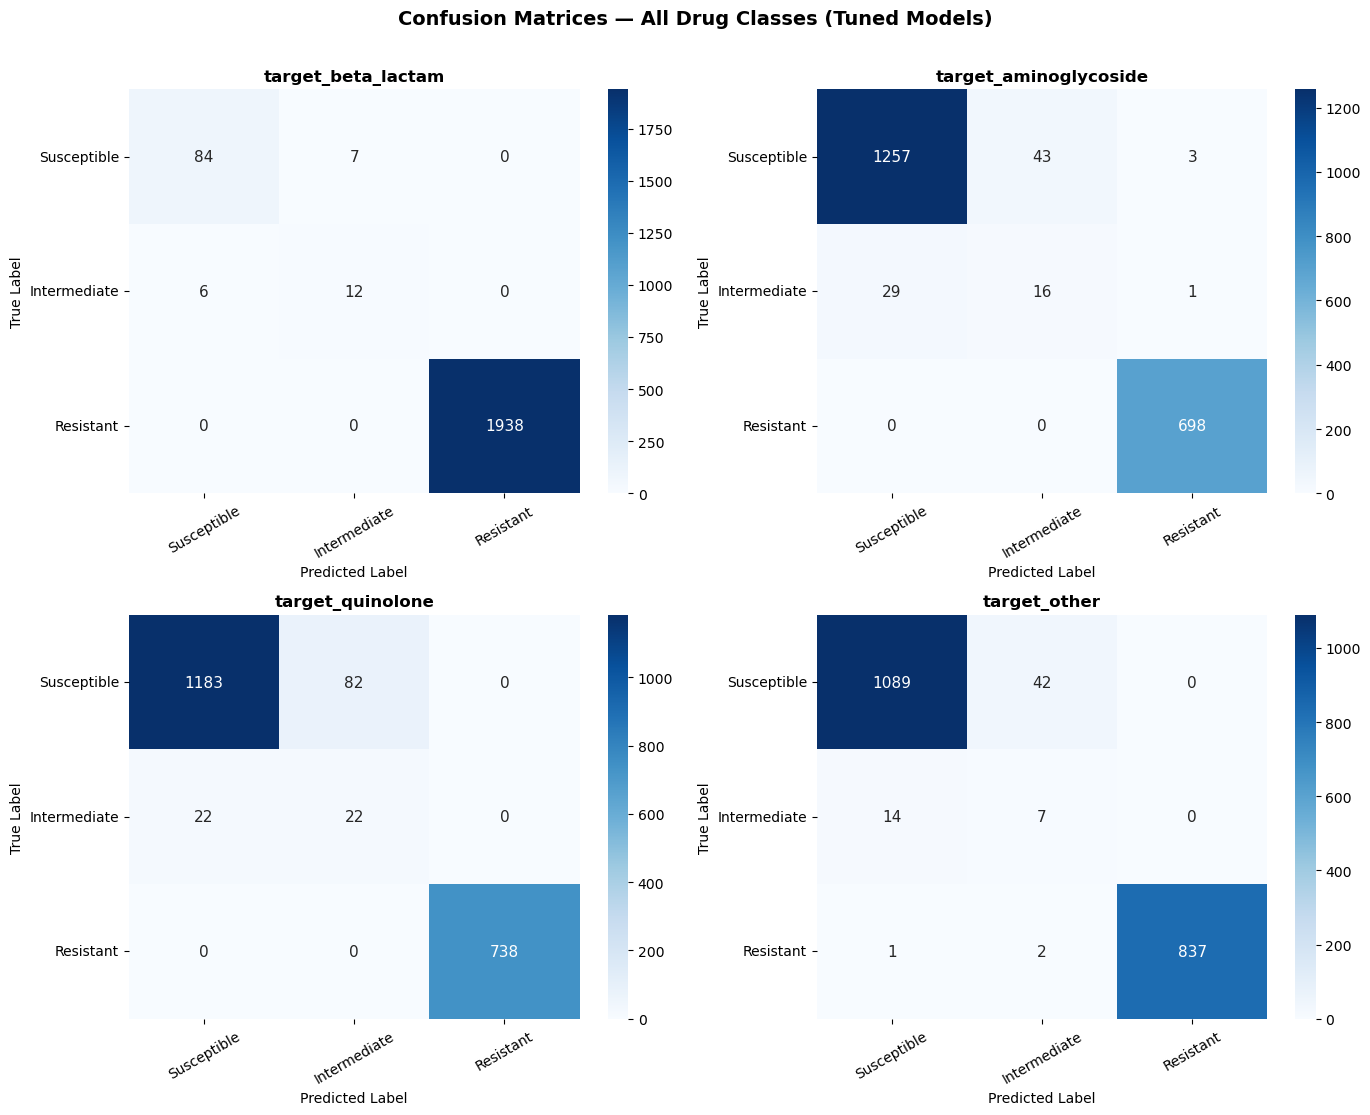

Saved: ../outputs/confusion_matrices_all.png


In [6]:
# ── Confusion Matrices — one figure, 2×2 grid ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    y_test = eval_store[target]['y_test']
    y_pred = eval_store[target]['y_pred']

    cm = confusion_matrix(y_test, y_pred)
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Susceptible','Intermediate','Resistant'],
                yticklabels=['Susceptible','Intermediate','Resistant'],
                annot_kws={'size': 11})
    ax.set_title(f'{target}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Confusion Matrices — All Drug Classes (Tuned Models)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/confusion_matrices_all.png")



CLASS-WISE METRICS SUMMARY
        Target        Class  Precision  Recall  F1-Score  Support
   beta_lactam  Susceptible      0.933   0.923     0.928       91
   beta_lactam Intermediate      0.632   0.667     0.649       18
   beta_lactam    Resistant      1.000   1.000     1.000     1938
aminoglycoside  Susceptible      0.977   0.965     0.971     1303
aminoglycoside Intermediate      0.271   0.348     0.305       46
aminoglycoside    Resistant      0.994   1.000     0.997      698
     quinolone  Susceptible      0.982   0.935     0.958     1265
     quinolone Intermediate      0.212   0.500     0.297       44
     quinolone    Resistant      1.000   1.000     1.000      738
         other  Susceptible      0.986   0.963     0.974     1131
         other Intermediate      0.137   0.333     0.194       21
         other    Resistant      1.000   0.996     0.998      840


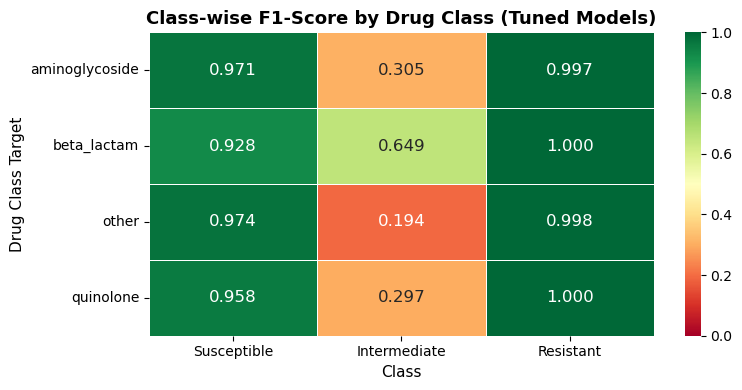

Saved: ../outputs/classwise_f1_heatmap.png


In [7]:
# ── Class-wise Precision / Recall / F1 summary table ─────────────────────────
class_labels = ['Susceptible', 'Intermediate', 'Resistant']
rows = []

for target in TARGET_COLS:
    y_test = eval_store[target]['y_test']
    y_pred = eval_store[target]['y_pred']

    report = classification_report(y_test, y_pred,
                 target_names=class_labels,
                 output_dict=True, zero_division=0)

    for cls in class_labels:
        if cls in report:
            rows.append({
                'Target'   : target.replace('target_', ''),
                'Class'    : cls,
                'Precision': round(report[cls]['precision'], 3),
                'Recall'   : round(report[cls]['recall'],    3),
                'F1-Score' : round(report[cls]['f1-score'],  3),
                'Support'  : int(report[cls]['support']),
            })

classwise_df = pd.DataFrame(rows)

print("\n" + "="*65)
print("CLASS-WISE METRICS SUMMARY")
print("="*65)
print(classwise_df.to_string(index=False))

# ── Heatmap: F1 per class per target ─────────────────────────────────────────
pivot_f1 = classwise_df.pivot(index='Target', columns='Class', values='F1-Score')
pivot_f1 = pivot_f1[['Susceptible', 'Intermediate', 'Resistant']]  # column order

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 12})
ax.set_title('Class-wise F1-Score by Drug Class (Tuned Models)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Drug Class Target', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/classwise_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/classwise_f1_heatmap.png")


In [8]:
# ── Best Hyperparameters Summary ─────────────────────────────────────────────
print("\n" + "="*65)
print("BEST HYPERPARAMETERS — ALL TARGETS")
print("="*65)

param_rows = []
for target, params in best_params_all.items():
    row = {'Target': target.replace('target_', '')}
    row.update(params)
    param_rows.append(row)

params_df = pd.DataFrame(param_rows).set_index('Target')
print(params_df.to_string())



BEST HYPERPARAMETERS — ALL TARGETS
                subsample  n_estimators  min_child_weight  max_depth  learning_rate  gamma  colsample_bytree
Target                                                                                                      
beta_lactam           0.7           200                 1          6            0.1    0.1               0.6
aminoglycoside        0.7           200                 1          6            0.1    0.1               0.6
quinolone             0.6           500                 7          7            0.1    0.0               0.7
other                 0.6           500                 7          7            0.1    0.0               0.7


#### Overall Results Summary

In [9]:
print("\n" + "="*65)
print("FINAL RESULTS SUMMARY — OVERALL METRICS")
print("="*65)
summary = pd.DataFrame(results).T
print(summary.round(3).to_string())



FINAL RESULTS SUMMARY — OVERALL METRICS
                       weighted_f1  macro_f1  accuracy  roc_auc  cv_mean  cv_std
target_beta_lactam           0.994     0.859     0.994    1.000    0.994   0.002
target_aminoglycoside        0.965     0.758     0.963    0.990    0.965   0.011
target_quinolone             0.959     0.752     0.949    0.990    0.970   0.002
target_other                 0.976     0.722     0.970    0.996    0.987   0.002


#### SHAP ANALYSIS FOR FEATURE IMPORTANCE


[SHAP] Computing feature importance (Interventional, per-class features)...

── Processing Target: target_beta_lactam ──


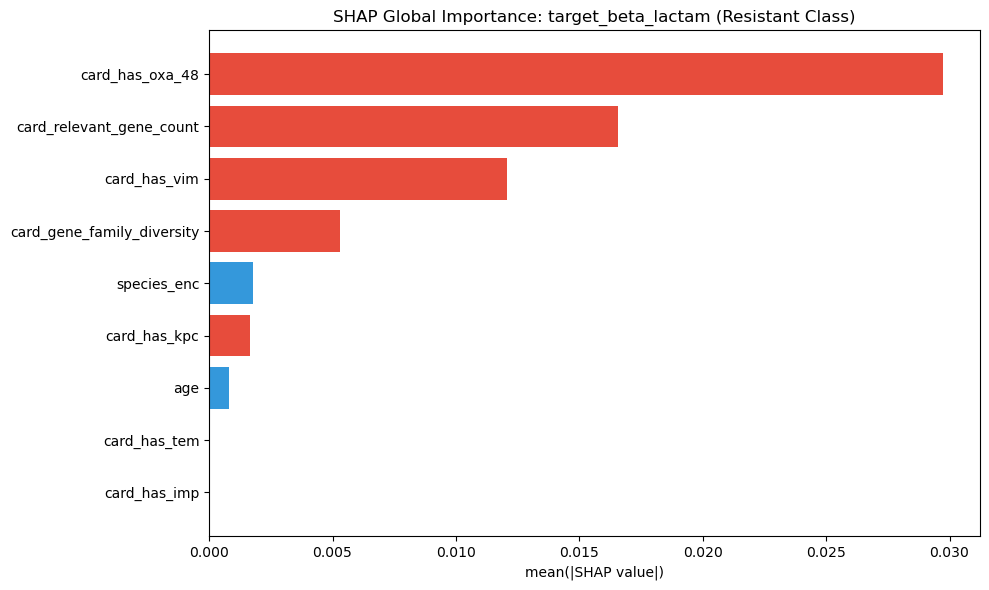

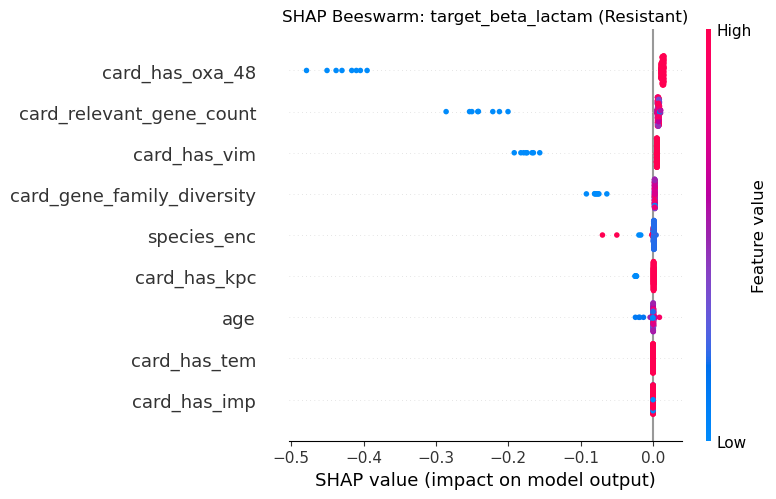


── Processing Target: target_aminoglycoside ──


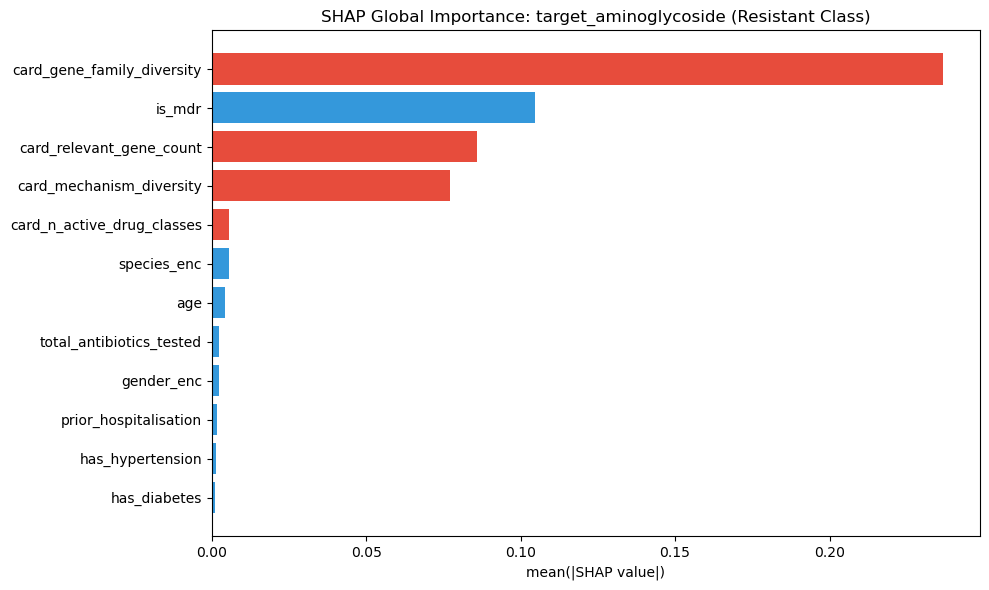

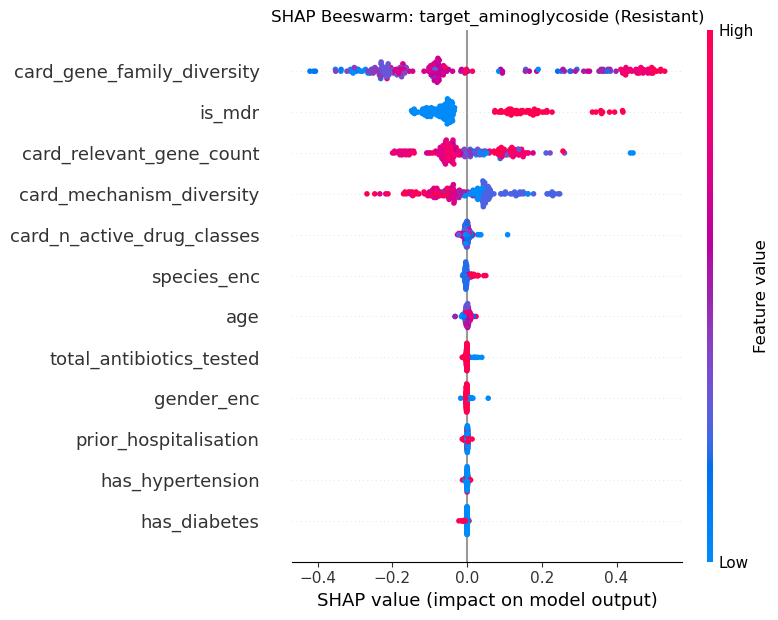


── Processing Target: target_quinolone ──


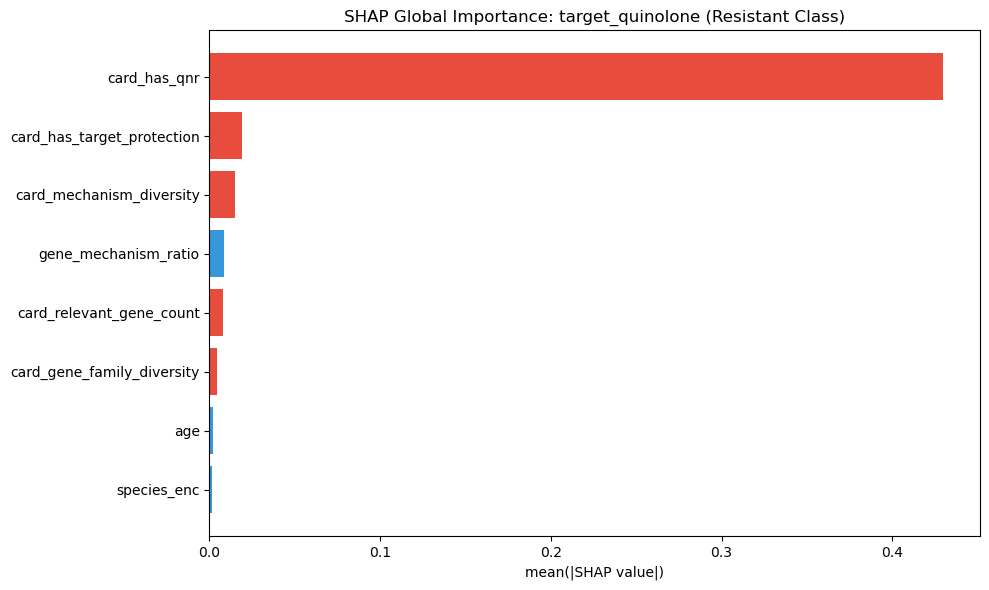

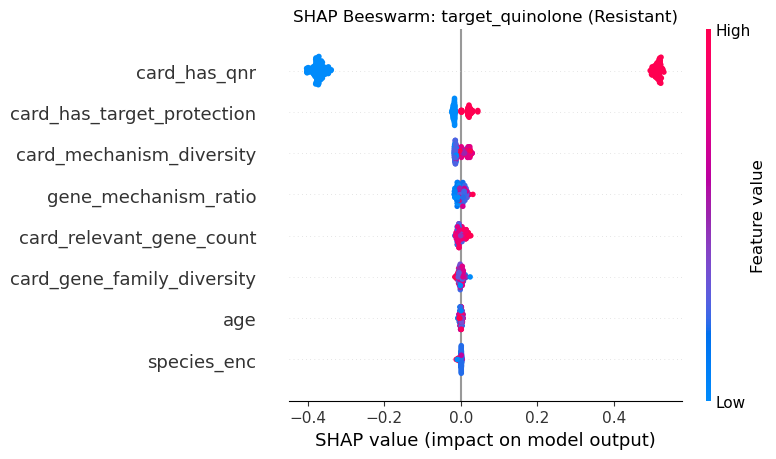


── Processing Target: target_other ──


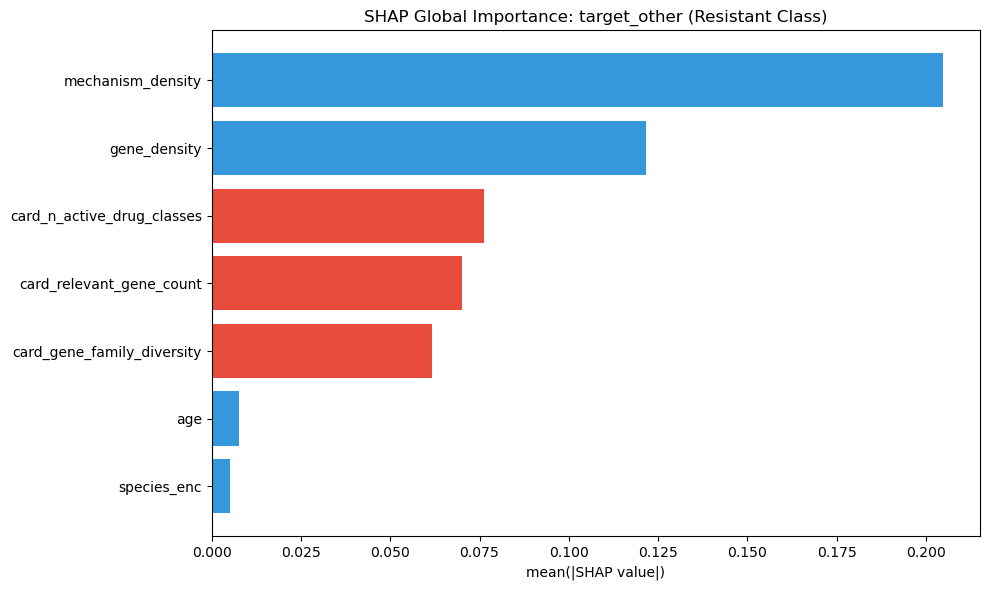

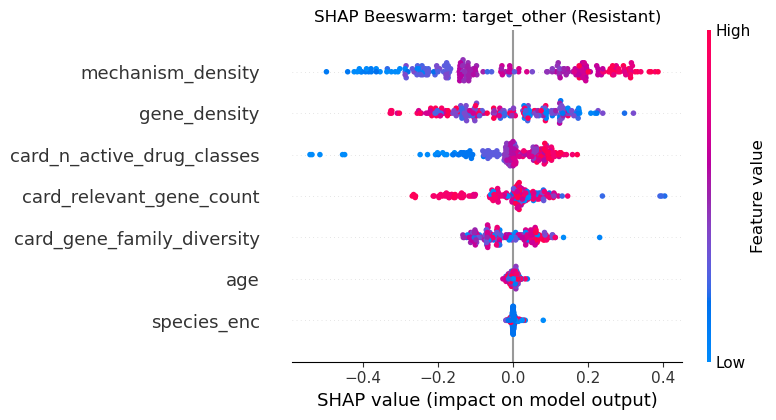


✓ All SHAP plots saved using per-class features (no feature mismatch).


In [10]:
os.makedirs('../outputs', exist_ok=True)
print("\n[SHAP] Computing feature importance (Interventional, per-class features)...")

for target in TARGET_COLS:
    print(f"\n── Processing Target: {target} ──")

    model    = trained_models[target]
    features = DRUG_CLASS_FEATURES[target]          # ← same features model was trained on

    data = df[df[target].notna()].copy()

    # Use DRUG_CLASS_FEATURES — not CLEAN_FEATURES — to match model input shape
    X_background = data[features].fillna(0).sample(min(100, len(data)), random_state=42)
    X_shap_test  = data[features].fillna(0).sample(min(200, len(data)), random_state=42)

    explainer   = shap.Explainer(model.predict_proba, X_background)
    shap_values = explainer(X_shap_test)

    # shap_values.values shape: (samples, features, classes) for multiclass
    if len(shap_values.values.shape) == 3:
        sv_resistant = shap_values.values[:, :, 2]          # class 2 = Resistant
        base_val     = (shap_values.base_values[0, 2]
                        if hasattr(shap_values.base_values, 'shape')
                        else shap_values.base_values[2])
    else:
        sv_resistant = shap_values.values
        base_val     = shap_values.base_values

    # ── Global Importance Bar Chart ───────────────────────────────────────────
    mean_abs_shap = np.abs(sv_resistant).mean(axis=0)
    # Index must match model features — len(features) == len(mean_abs_shap)
    importance_df = pd.Series(mean_abs_shap, index=features).sort_values(ascending=False)

    top_n  = min(15, len(features))
    top_ft = importance_df.head(top_n)
    colors = ['#e74c3c' if 'card' in f.lower() else '#3498db' for f in top_ft.index]

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), top_ft.values[::-1], color=colors[::-1])
    plt.yticks(range(top_n), top_ft.index[::-1])
    plt.title(f'SHAP Global Importance: {target} (Resistant Class)')
    plt.xlabel('mean(|SHAP value|)')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_bar_{target}.png', dpi=120)
    plt.show()

    # ── Beeswarm Plot ─────────────────────────────────────────────────────────
    exp_obj = shap.Explanation(
        values       = sv_resistant,
        base_values  = base_val,
        data         = X_shap_test.values,
        feature_names= features,               # ← matches model input
    )

    plt.figure(figsize=(10, 8))
    shap.plots.beeswarm(exp_obj, max_display=top_n, show=False)
    plt.title(f'SHAP Beeswarm: {target} (Resistant)')
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_beeswarm_{target}.png', dpi=120)
    plt.show()

print("\n✓ All SHAP plots saved using per-class features (no feature mismatch).")


In [11]:
for target, model in trained_models.items():
    fname = f'../models/xgb_{target.replace("target_", "")}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved: {fname}")

print("\nAll models saved to ../models/")

Saved: ../models/xgb_beta_lactam.pkl
Saved: ../models/xgb_aminoglycoside.pkl
Saved: ../models/xgb_quinolone.pkl
Saved: ../models/xgb_other.pkl

All models saved to ../models/
